In [36]:
import os
import cv2
import numpy as np
import pandas as pd
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from tqdm import tqdm
from collections import Counter

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

In [5]:
ROOT_PATH = "clean_dataset/"
IMAGE_DIR = ROOT_PATH + "Images/"
OUTPUT_DIR = "output/"
IMG_SIZE = (128, 128)
HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (8, 8)
HOG_CELLS_PER_BLOCK = (2, 2)
USE_COLOR_HIST = True
COLOR_HIST_BINS = 32
USE_LBP = True
LBP_RADIUS = 3
LBP_N_POINTS = 24
TEST_SIZE = 0.20
CV_FOLDS = 5
USE_PCA = True
PCA_VARIANCE = 0.95
AUG_PER_IMAGE = 4

In [6]:
df = pd.read_csv(ROOT_PATH + "annotation.csv")
df["filepath"] = df["filename"].apply(lambda x: str(Path(IMAGE_DIR) / x))
df = df[df["filepath"].apply(os.path.exists)].reset_index(drop=True)

df.head()

,image_index,filename,class,filepath
0,0,image_0.png,With Helmet,clean_dataset/Images/image_0.png
1,1,image_1.png,With Helmet,clean_dataset/Images/image_1.png
2,2,image_2.png,Without Helmet,clean_dataset/Images/image_2.png
3,3,image_3.png,Without Helmet,clean_dataset/Images/image_3.png
4,4,image_4.png,Without Helmet,clean_dataset/Images/image_4.png


In [7]:
images = []
labels = []
for _, row in tqdm(df.iterrows(), total=len(df), desc="Loading images"):
    img = cv2.imread(row["filepath"])
    if img is not None:
        img = cv2.resize(img, (IMG_SIZE[1], IMG_SIZE[0]))
        images.append(img)
        labels.append(row["class"])

Loading images: 100%|██████████| 1451/1451 [00:00<00:00, 3340.34it/s]


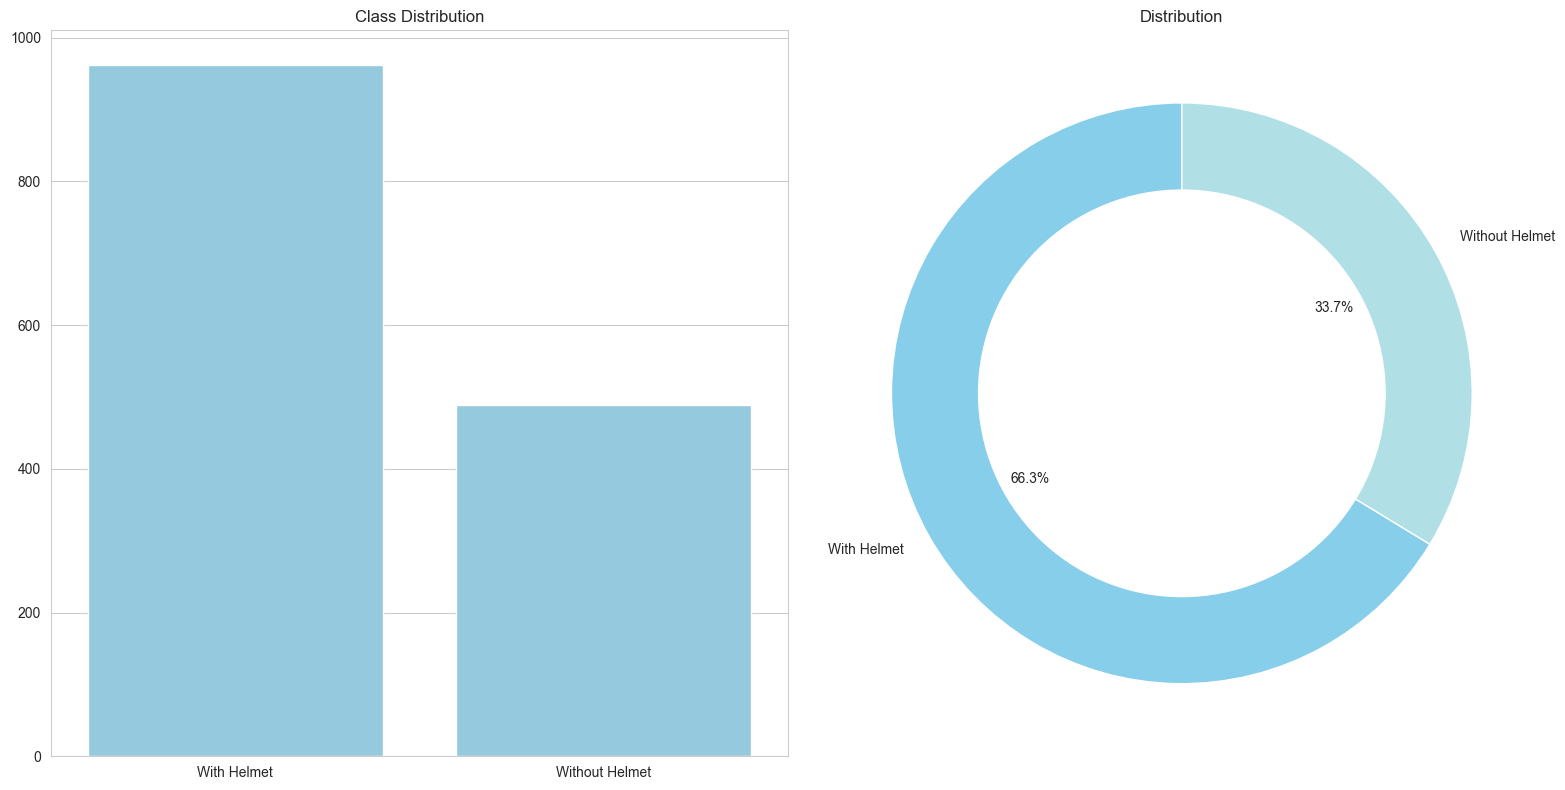

In [8]:
label_counts = Counter(labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(x=label_counts.keys(), y=label_counts.values(), ax=axes[0], color='skyblue', zorder=2)
axes[0].grid(True, axis='y')
axes[0].set_title("Class Distribution")

axes[1].pie(
    label_counts.values(), 
    labels=label_counts.keys(), 
    autopct="%1.1f%%",
    startangle=90,
    colors=["skyblue", "powderblue"]
)

axes[1].set_title('Distribution')

centre_circle = plt.Circle((0,0), 0.70, fc='white')
axes[1].add_artist(centre_circle)

plt.tight_layout()
plt.show()

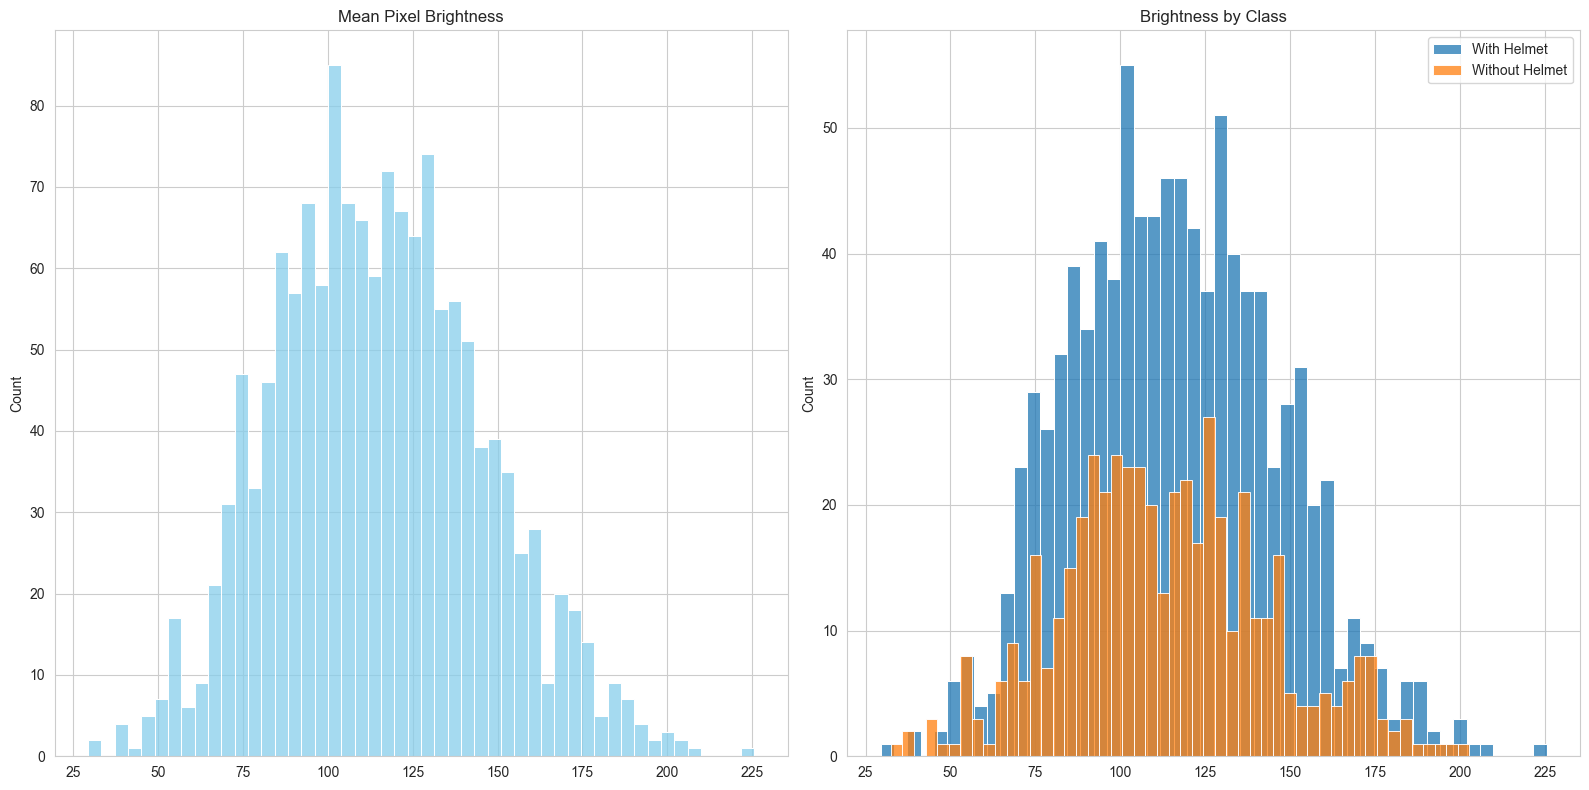

In [9]:
heights = [img.shape[0] for img in images]
widths = [img.shape[1] for img in images]
means = [img.mean() for img in images]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.histplot(data=means, bins=50, color='skyblue', ax=axes[0], zorder=2)
axes[0].set_title("Mean Pixel Brightness")

class_means = {cls: [] for cls in label_counts}

for img, label in zip(images, labels):
    class_means[label].append(img.mean())

for cls, vals in class_means.items():
    sns.histplot(data=vals, bins=50, label=cls, ax=axes[1])

axes[1].set_title("Brightness by Class")
axes[1].legend()

plt.tight_layout()
plt.show()

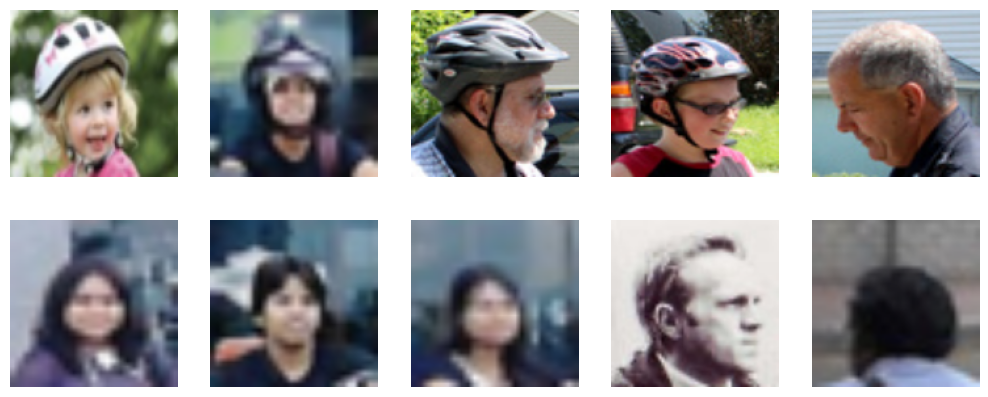

In [10]:
n_per_class = min(5, min(label_counts.values()))

fig, axes = plt.subplots(len(label_counts), n_per_class, figsize=(n_per_class * 2.5, len(label_counts) * 2.5))

if len(label_counts) == 1:
    axes = [axes]

for row_idx, cls in enumerate(label_counts.keys()):
    cls_imgs = [img for img, lbl in zip(images, labels) if lbl == cls]
    
    for col_idx, img in enumerate(cls_imgs[:n_per_class]):
        ax = axes[row_idx][col_idx]
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.axis("off")
        if col_idx == 0:
            ax.set_ylabel(cls, fontsize=9)

plt.show()

In [11]:
def augment_image(img):
    augmented = []
    augmented.append(cv2.flip(img, 1))
    alpha = np.random.uniform(0.7, 1.3)
    beta = np.random.randint(-30, 30)
    augmented.append(cv2.convertScaleAbs(img, alpha=alpha, beta=beta))
    h, w = img.shape[:2]
    angle = np.random.uniform(-15, 15)
    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    augmented.append(cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT))
    noise = np.random.normal(0, 15, img.shape).astype(np.int16)
    augmented.append(np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8))
    return augmented[:AUG_PER_IMAGE]

In [12]:
label_counts = Counter(labels)
min_class = min(label_counts, key=label_counts.get)
print(f"Augmenting minority class: {min_class}")
aug_images, aug_labels = list(images), list(labels)
for img, lbl in tqdm(zip(images, labels), total=len(images), desc="Augmenting"):
    if lbl == min_class:
        variants = augment_image(img)
        aug_images.extend(variants)
        aug_labels.extend([lbl] * len(variants))
images, labels = aug_images, aug_labels
print(f"Dataset size: {len(images)} images")


Augmenting minority class: Without Helmet


Augmenting: 100%|██████████| 1451/1451 [00:00<00:00, 2335.42it/s]

Dataset size: 3407 images


In [13]:
def extract_hog(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    win_size = (IMG_SIZE[1], IMG_SIZE[0])
    hog = cv2.HOGDescriptor(
        win_size, 
        (HOG_CELLS_PER_BLOCK[0] * HOG_PIXELS_PER_CELL[0], HOG_CELLS_PER_BLOCK[1] * HOG_PIXELS_PER_CELL[1]), 
         HOG_PIXELS_PER_CELL, 
         HOG_CELLS_PER_BLOCK, 
         HOG_ORIENTATIONS
    )
    
    return hog.compute(gray).flatten()

In [14]:
def extract_color_histogram(img):
    hist = []
    for ch in range(3):
        h = cv2.calcHist([img], [ch], None, [COLOR_HIST_BINS], [0, 256])
        hist.append(cv2.normalize(h, h).flatten())

    return np.concatenate(hist)

In [15]:
def extract_lbp(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    lbp = np.zeros_like(gray, dtype=np.uint8)
    r, n = LBP_RADIUS, LBP_N_POINTS
    for i in range(n):
        angle = 2 * np.pi * i / n
        dx = int(round(r * np.cos(angle)))
        dy = int(round(-r * np.sin(angle)))
        shifted = np.roll(np.roll(gray, dy, axis=0), dx, axis=1)
        lbp += ((shifted >= gray).astype(np.uint8)) << i
    n_bins = 2 ** n if n <= 8 else 256
    hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins))
    hist = hist.astype(np.float32)
    hist /= (hist.sum() + 1e-7)
    return hist

In [16]:
def extract_features(img):
    features = [extract_hog(img)]
    if USE_COLOR_HIST:
        features.append(extract_color_histogram(img))
    if USE_LBP:
        features.append(extract_lbp(img))
    return np.concatenate(features)

In [17]:
X = np.array([extract_features(img) for img in tqdm(images, desc="Extracting features")], dtype=np.float32)

Extracting features: 100%|██████████| 3407/3407 [00:05<00:00, 605.06it/s]


In [18]:
le = LabelEncoder()
y = le.fit_transform(labels)

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=42)

In [20]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [21]:
pca = PCA(n_components=PCA_VARIANCE, random_state=42)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)
print(f"PCA: {X_train.shape[1]} components")

PCA: 1991 components


In [22]:
models = {
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7)
}

In [23]:
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

scaler_path = Path(OUTPUT_DIR) / "scaler.pkl"
encoder_path = Path(OUTPUT_DIR) / "encoder.pkl"
pca_path = Path(OUTPUT_DIR) / "pca.pkl"

joblib.dump(scaler, scaler_path)
joblib.dump(le, encoder_path)

if USE_PCA:
    joblib.dump(pca, pca_path)
    print(f"Saved: {scaler_path}, {pca_path}, {encoder_path}")
else:
    print(f"Saved: {scaler_path}, {encoder_path} (PCA disabled, pca.pkl not saved)")

Saved: output/scaler.pkl, output/pca.pkl, output/encoder.pkl


In [24]:
from pathlib import Path

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

scaler_path = Path(OUTPUT_DIR) / "scaler.pkl"
encoder_path = Path(OUTPUT_DIR) / "encoder.pkl"
pca_path = Path(OUTPUT_DIR) / "pca.pkl"

joblib.dump(scaler, scaler_path, compress=9)
joblib.dump(le, encoder_path, compress=9)

if USE_PCA:
    joblib.dump(pca, pca_path, compress=9)
    print(f"Saved: {scaler_path}, {pca_path}, {encoder_path}")
else:
    print(f"Saved: {scaler_path}, {encoder_path} (PCA disabled, pca.pkl not saved)")

Saved: output/scaler.pkl, output/pca.pkl, output/encoder.pkl


In [26]:
import joblib

trained_models = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained_models[name] = model

joblib.dump(trained_models, "models.pkl", compress=9)

['models.pkl']

In [31]:
import joblib

def load_models(model_path="models.pkl"):
    return joblib.load(model_path)

def infer_image(filepath, model_name="KNN", model_path="models.pkl"):
    models_dict = load_models(model_path)
    
    if model_name not in models_dict:
        raise ValueError(f"Model '{model_name}' not found. Available: {list(models_dict.keys())}")
    
    img = cv2.imread(filepath)
    if img is None:
        raise FileNotFoundError(f"Could not read image: {filepath}")
    
    img = cv2.resize(img, (IMG_SIZE[1], IMG_SIZE[0]))
    feat = extract_features(img).astype(np.float32).reshape(1, -1)
    
    feat = scaler.transform(feat)
    if USE_PCA:
        feat = pca.transform(feat)
    
    model = models_dict[model_name]
    pred_idx = model.predict(feat)[0]
    pred_label = le.inverse_transform([pred_idx])[0]
    
    prob = None
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(feat)[0]
    
    return {
        "model": model_name,
        "prediction": pred_label,
        "prediction_index": int(pred_idx),
        "probabilities": prob
    }

In [28]:
infer_image("/Users/School/60545823941a1.png")

{'model': 'KNN',
 'prediction': np.str_('Without Helmet'),
 'prediction_index': 1,
 'probabilities': array([0., 1.])}

In [29]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=42)
results = {}

In [30]:
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="f1_weighted", n_jobs=-1)
    results[name] = {"mean": scores.mean(), "std": scores.std()}
    print(f"  {name:20s}: F1={scores.mean():.4f} ± {scores.std():.4f}")

  SVM                 : F1=0.8129 ± 0.0092
  Random Forest       : F1=0.6677 ± 0.0127
  Gradient Boosting   : F1=0.7676 ± 0.0122
  Logistic Regression : F1=0.7731 ± 0.0332
  KNN                 : F1=0.6007 ± 0.0017


In [38]:
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    y_score = None
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
        y_score = y_proba[:, 1] if y_proba.ndim == 2 and y_proba.shape[1] > 1 else y_proba.ravel()
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
        if y_score.ndim > 1 and y_score.shape[1] > 1:
            y_score = y_score[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")

    roc_auc = np.nan
    if y_score is not None and len(np.unique(y_test)) == 2:
        try:
            roc_auc = roc_auc_score(y_test, y_score)
        except ValueError:
            roc_auc = np.nan

    cm = confusion_matrix(y_test, y_pred)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
    axes[0].set_title(f"{name} - Confusion Matrix")
    axes[0].grid(False)

    if y_score is not None and len(np.unique(y_test)) == 2:
        fpr, tpr, _ = roc_curve(y_test, y_score)
        axes[1].plot(fpr, tpr, color="#1E88E5", lw=2, label=f"AUC = {roc_auc:.4f}")
        axes[1].plot([0, 1], [0, 1], "k--", lw=1)
        axes[1].set_title(f"{name} - ROC Curve")
        axes[1].set_xlabel("False Positive Rate")
        axes[1].set_ylabel("True Positive Rate")
        axes[1].legend(loc="lower right")
    else:
        axes[1].axis("off")
        axes[1].text(0.5, 0.5, "ROC curve not available", ha="center", va="center")

    plt.tight_layout()
    plt.show()

    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "Weighted F1 Score": weighted_f1,
        "ROC-AUC": roc_auc,
        "Confusion Matrix": cm,
        "y_pred": y_pred,
        "y_score": y_score,
    }

model_results = []


Evaluating SVM


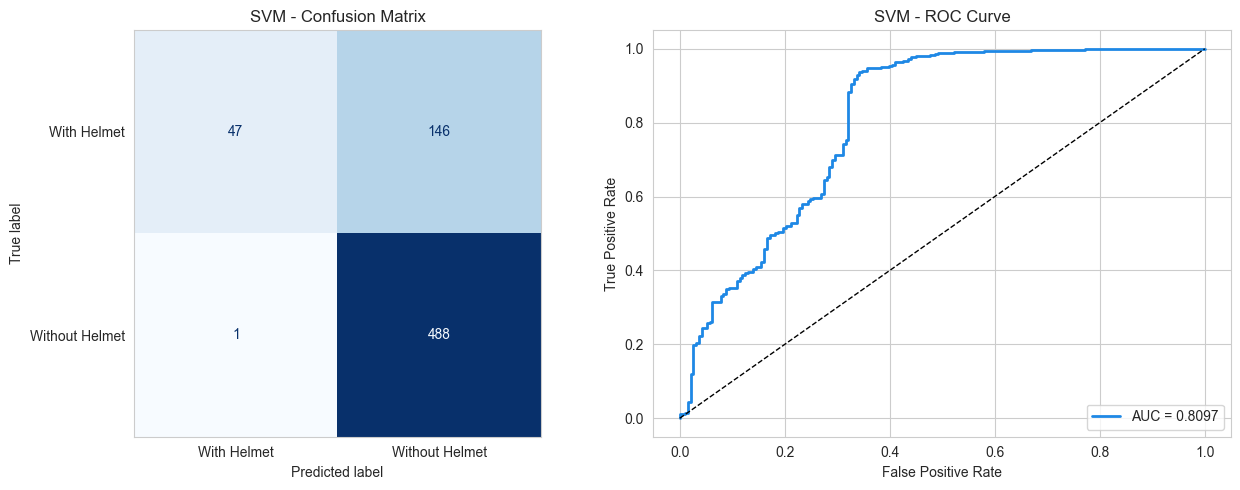


Evaluating Random Forest


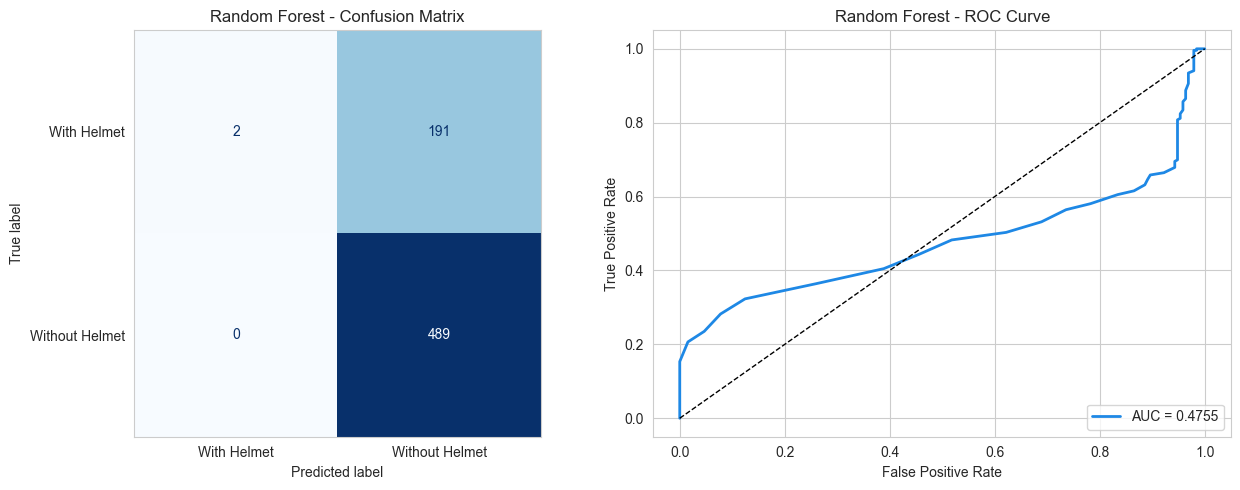


Evaluating Gradient Boosting


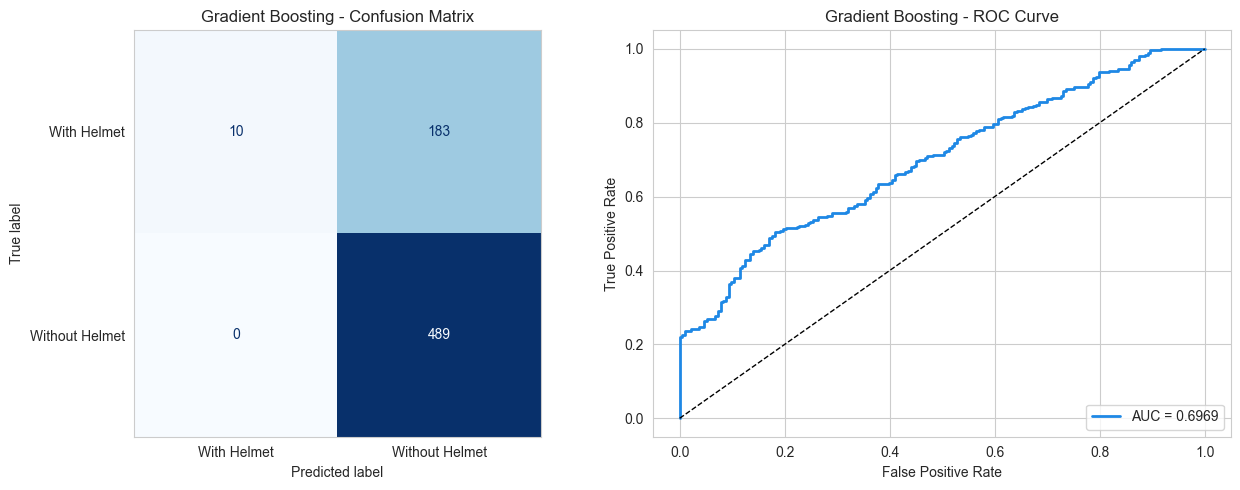


Evaluating Logistic Regression


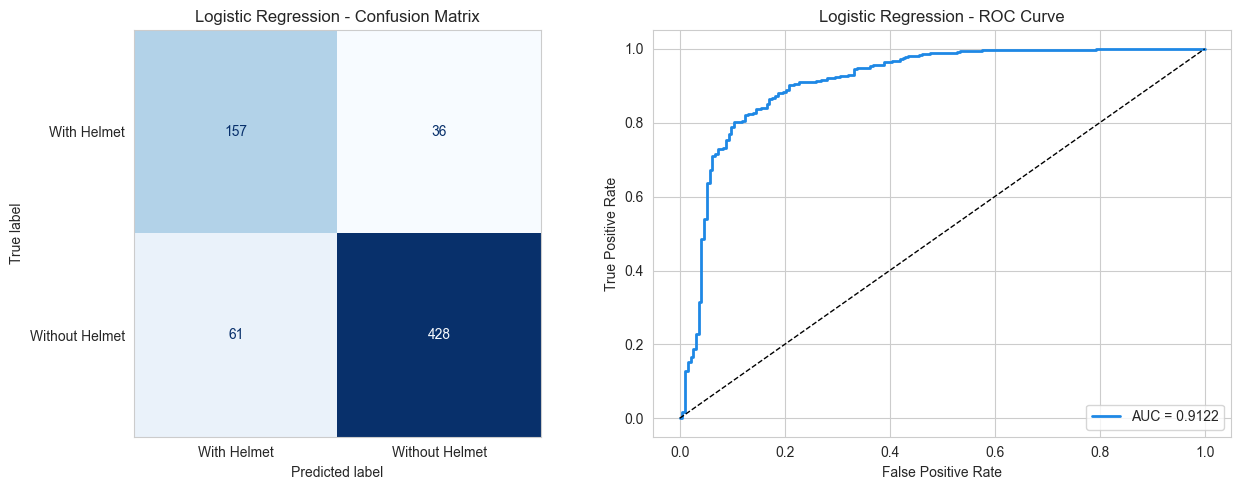


Evaluating KNN


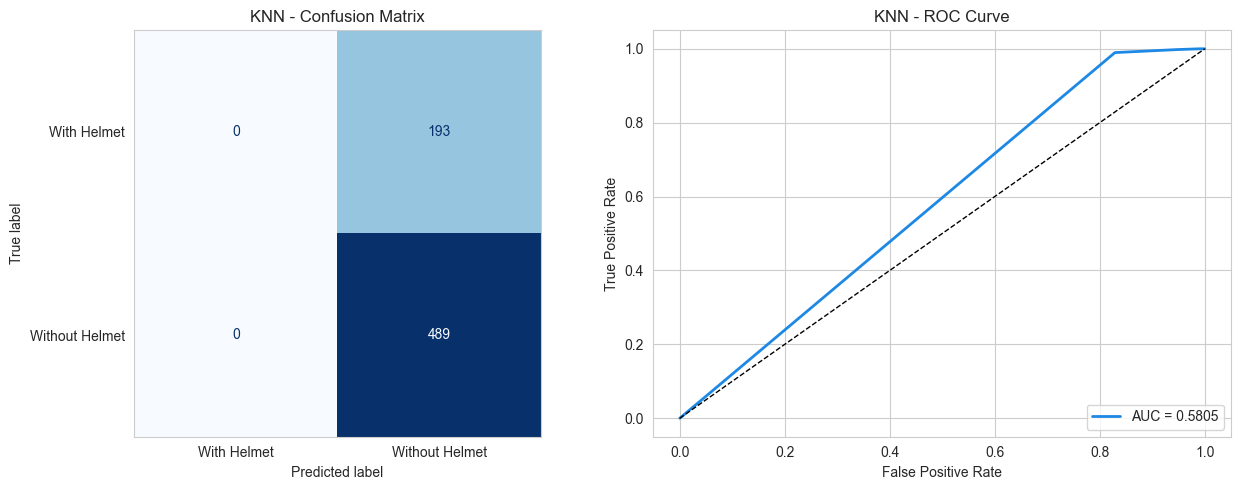

In [39]:
for name, model in models.items():
    print(f"\nEvaluating {name}")
    model_results.append(evaluate_model(name, model, X_train, y_train, X_test, y_test))

In [40]:
results_df = pd.DataFrame(model_results)
results_df = results_df[["Model", "Accuracy", "Precision", "Recall", "Weighted F1 Score", "ROC-AUC"]]
results_df = results_df.sort_values("Weighted F1 Score", ascending=False).reset_index(drop=True)

print("\nModel Comparison:")
print(results_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

best_model_name = results_df.loc[0, "Model"]
print(f"\nBest model by weighted F1: {best_model_name}")


Model Comparison:
              Model  Accuracy  Precision  Recall  Weighted F1 Score  ROC-AUC
Logistic Regression    0.8578     0.8652  0.8578             0.8602   0.9122
                SVM    0.7845     0.8290  0.7845             0.7335   0.8097
  Gradient Boosting    0.7317     0.8047  0.7317             0.6319   0.6969
      Random Forest    0.7199     0.7986  0.7199             0.6057   0.4755
                KNN    0.7170     0.5141  0.7170             0.5988   0.5805

Best model by weighted F1: Logistic Regression
